# Stage 1: Environment Setup + Pose Estimation

**Goal:** Given a full-body photo of a person, detect their body pose (skeleton keypoints).  
This is the foundation of virtual try-on — we need to know *where* the body parts are  
before we can map clothing onto them.

**What we'll do:**
1. Verify GPU access and install dependencies
2. Set up Google Drive for persistent storage
3. Download a test image
4. Run MediaPipe pose estimation to extract body keypoints
5. Visualize the results

## Cell 1: GPU Check & Install Dependencies

**Why GPU?** Pose estimation models run much faster on GPU. Colab's free T4 GPU  
gives us ~16GB VRAM — more than enough for this stage.

**MediaPipe** is Google's lightweight ML framework for body/hand/face detection.  
It runs pose estimation in real-time and gives us 33 body landmarks (x, y, z coordinates).

In [4]:
# Check GPU availability
!nvidia-smi

import torch
print(f"\nPyTorch sees GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Fri May 22 20:32:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Install dependencies
!pip install mediapipe opencv-python-headless matplotlib gdown -q
print("All packages installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 15.2 MB/s eta 0:00:00
All packages installed.


## Cell 2: Mount Google Drive & Create Project Folders

**Why Google Drive?** Colab VMs are ephemeral — they shut down after ~90 min of inactivity  
and all local files are lost. Google Drive persists across sessions.

**Folder structure:**
```
VirtualTryOn/
  input_images/    -- raw person photos and clothing images
  output_images/   -- pose overlays, segmentation masks, try-on results
  checkpoints/     -- saved model weights (for later stages)
```

In [5]:
from google.colab import drive
import os

drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/VirtualTryOn'
SUBDIRS = ['input_images', 'output_images', 'checkpoints']

for sub in SUBDIRS:
    path = os.path.join(BASE_DIR, sub)
    os.makedirs(path, exist_ok=True)
    print(f"Ready: {path}")

print(f"\nProject root: {BASE_DIR}")

Mounted at /content/drive
Ready: /content/drive/MyDrive/VirtualTryOn/input_images
Ready: /content/drive/MyDrive/VirtualTryOn/output_images
Ready: /content/drive/MyDrive/VirtualTryOn/checkpoints

Project root: /content/drive/MyDrive/VirtualTryOn


## Cell 3: Download a Test Image

We need a **full-body** photo of a person standing upright. This is important because:
- MediaPipe needs to see most of the body to detect the pose
- Virtual try-on works best with front-facing, roughly centered subjects

We're using a sample from the DeepFashion dataset (a standard benchmark in fashion CV).

In [8]:
# Option 1: Upload your own photo (recommended)
from google.colab import files
import cv2
if not os.path.exists(TEST_IMAGE_PATH):
    print("Upload a full-body person photo (front-facing works best):")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    import shutil
    shutil.move(fname, TEST_IMAGE_PATH)
    print(f"Saved to: {TEST_IMAGE_PATH}")
else:
    print(f"Image already exists: {TEST_IMAGE_PATH}")

img = cv2.imread(TEST_IMAGE_PATH)
print(f"Image shape: {img.shape}")

Image already exists: /content/drive/MyDrive/VirtualTryOn/input_images/test_person.jpg
Image shape: (1280, 561, 3)


## Cell 4: Pose Estimation with MediaPipe

**How pose estimation works (simplified):**
1. A neural network scans the image and detects the person's bounding box
2. A second network predicts 33 body landmarks (joints) within that box
3. Each landmark has (x, y) normalized to [0,1] relative to image size, plus a confidence score

**Key landmarks for virtual try-on:**
- Shoulders (11, 12) — define the top of the torso where shirts sit
- Hips (23, 24) — define the waistline for pants/skirts
- Knees (25, 26) — needed for full-length garments

**Why this matters for try-on:** Knowing joint positions lets us:
- Calculate torso width/height to scale the clothing image
- Determine the angle of the body to warp clothing accordingly
- Identify which body region each garment piece should cover

In [15]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import cv2
import numpy as np
import os

# Download the pose landmarker model
!wget -q https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task -O /tmp/pose_landmarker.task

image_bgr = cv2.imread(TEST_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w, _ = image_rgb.shape

# Configure and run the landmarker
options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path='/tmp/pose_landmarker.task'),
    running_mode=vision.RunningMode.IMAGE,
    min_pose_detection_confidence=0.5
)

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    results = landmarker.detect(mp_image)

if not results.pose_landmarks:
    print("ERROR: No pose detected!")
else:
    print("Pose detected successfully!\n")

    landmarks = results.pose_landmarks[0]
    annotated = image_rgb.copy()

    # Draw connections manually
    CONNECTIONS = [
        (11,12),(11,13),(13,15),(12,14),(14,16),  # arms
        (11,23),(12,24),(23,24),                   # torso
        (23,25),(25,27),(24,26),(26,28),           # legs
    ]
    for a, b in CONNECTIONS:
        x1, y1 = int(landmarks[a].x * w), int(landmarks[a].y * h)
        x2, y2 = int(landmarks[b].x * w), int(landmarks[b].y * h)
        cv2.line(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Draw joint dots
    for lm in landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(annotated, (cx, cy), 4, (255, 0, 0), -1)

    # Save output
    OUTPUT_DIR = os.path.join(BASE_DIR, 'output_images')
    output_path = os.path.join(OUTPUT_DIR, 'pose_output.jpg')
    cv2.imwrite(output_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
    print(f"Saved pose overlay to: {output_path}\n")

    # Print key landmarks
    KEY_POINTS = {
        'Left Shoulder':  11, 'Right Shoulder': 12,
        'Left Hip':       23, 'Right Hip':      24,
        'Left Knee':      25, 'Right Knee':     26,
    }
    print(f"{'Landmark':<20} {'Pixel (x, y)':<20} Confidence")
    print('-' * 55)
    for name, idx in KEY_POINTS.items():
        lm = landmarks[idx]
        px, py = int(lm.x * w), int(lm.y * h)
        print(f"{name:<20} ({px:>4}, {py:>4})       {lm.visibility:.3f}")

    ls, rs, lh, rh = landmarks[11], landmarks[12], landmarks[23], landmarks[24]
    print(f"\nTorso metrics:")
    print(f"  Shoulder width: {abs(ls.x - rs.x) * w:.0f} px")
    print(f"  Torso height:   {abs(((ls.y+rs.y)/2) - ((lh.y+rh.y)/2)) * h:.0f} px")

Pose detected successfully!

Saved pose overlay to: /content/drive/MyDrive/VirtualTryOn/output_images/pose_output.jpg

Landmark             Pixel (x, y)         Confidence
-------------------------------------------------------
Left Shoulder        ( 373,  704)       1.000
Right Shoulder       ( 223,  702)       1.000
Left Hip             ( 337,  922)       1.000
Right Hip            ( 246,  918)       1.000
Left Knee            ( 329, 1074)       0.984
Right Knee           ( 223, 1071)       0.987

Torso metrics:
  Shoulder width: 150 px
  Torso height:   217 px


## Cell 5: Visualize Original vs Pose-Detected

Side-by-side comparison lets us verify the pose estimation quality.  
Look for:
- Are the shoulder/hip joints correctly placed?
- Is the skeleton roughly symmetric?
- Are confidence scores above 0.8 for key joints?

If the skeleton looks wrong, the test image might have occlusion or an unusual pose.  
Try a clearer, front-facing full-body photo.

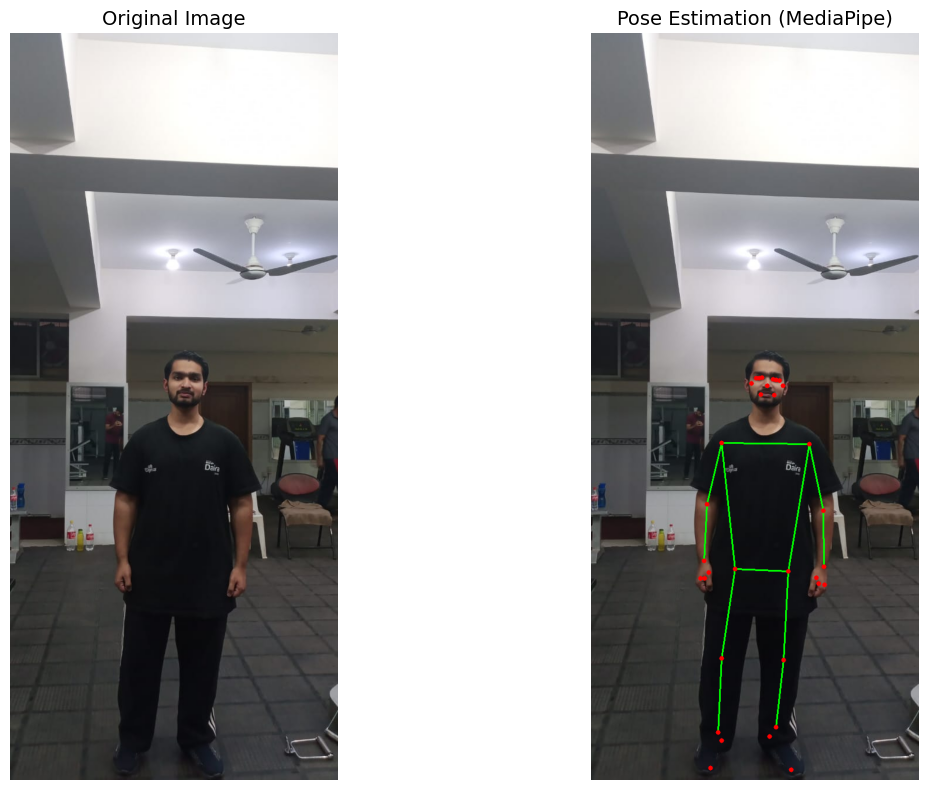

Stage 1 complete! Pose estimation is working.
Next: Stage 2 - Body Segmentation (waiting for your go-ahead)


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

axes[0].imshow(image_rgb)
axes[0].set_title('Original Image', fontsize=14)
axes[0].axis('off')

axes[1].imshow(annotated)
axes[1].set_title('Pose Estimation (MediaPipe)', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison.jpg'), dpi=150, bbox_inches='tight')
plt.show()

print("Stage 1 complete! Pose estimation is working.")
print("Next: Stage 2 - Body Segmentation (waiting for your go-ahead)")

---
## What we learned in Stage 1

- **Pose estimation** gives us a skeleton (33 keypoints) overlaid on a person image
- The 6 key joints (shoulders, hips, knees) define where clothing attaches to the body
- **Torso width/height** from keypoints will later be used to scale clothing images
- Everything is saved to Google Drive so it persists across Colab sessions

### How this connects to the full pipeline:
```
Person Image
    |
    v
[Stage 1: Pose Estimation]  <-- YOU ARE HERE
    |  (skeleton keypoints)
    v
[Stage 2: Body Segmentation]
    |  (pixel-level body part masks)
    v
[Stage 3: Clothing Warping]
    |  (deform clothing to match pose)
    v
[Stage 4: Try-On Synthesis]
    |  (blend warped clothing onto person)
    v
Output Image
```